<a href="https://colab.research.google.com/github/gulay00/HackerRank/blob/python%2Fbasic/Crack_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!unzip  "/content/Conglomerate Concrete Crack Detection.zip"

unzip:  cannot find or open /content/Conglomerate Concrete Crack Detection.zip, /content/Conglomerate Concrete Crack Detection.zip.zip or /content/Conglomerate Concrete Crack Detection.zip.ZIP.


In [14]:
import tensorflow as tf
import os

def load_image_mask(image_path, mask_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels = 3)
    image = tf.image.resize(image, (256, 256))
    image = tf.cast(image, tf.float32) / 255


    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels = 1)
    mask = tf.image.resize(mask, (256, 256))
    mask = tf.cast(mask, tf.float32) / 255

    return image, mask


def augment(image, mask):
    # Random flip


    return image, mask




def create_dataset(image_dir, mask_dir, batch_size=16, augment_data=False):
    image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
    mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)


    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.shuffle(buffer_size=1000) if augment_data else dataset
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset




train_dataset = create_dataset(
    image_dir='/content/Conglomerate Concrete Crack Detection/Train/images',
    mask_dir='/content/Conglomerate Concrete Crack Detection/Train/masks',
    batch_size=16,
    augment_data=True
)

val_dataset = create_dataset(
    image_dir='/content/Conglomerate Concrete Crack Detection/Test/images',
    mask_dir='/content/Conglomerate Concrete Crack Detection/Test/masks',
    batch_size=16,
    augment_data=False
)

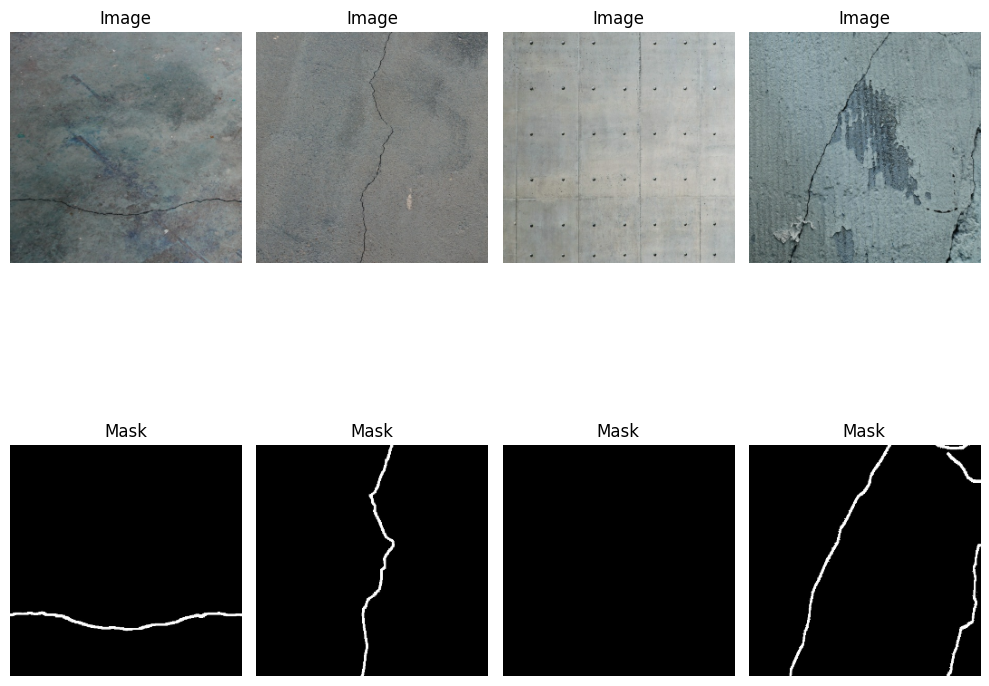

In [15]:
import random
import matplotlib.pyplot as plt

image_paths = '/content/Conglomerate Concrete Crack Detection/Train/images'
mask_paths = '/content/Conglomerate Concrete Crack Detection/Train/masks'

image_paths = sorted([os.path.join(image_paths, fname) for fname in os.listdir(image_paths)])
mask_paths = sorted([os.path.join(mask_paths, fname) for fname in os.listdir(mask_paths)])


idx = random.sample(range(len(image_paths)), 4)

plt.figure(figsize = (10, 10))

for i in range(4):
    img, msk = load_image_mask(image_paths[idx[i]], mask_paths[idx[i]])

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title('Image')
    plt.axis('off')

    plt.subplot(2, 4, i + 5)
    plt.imshow(msk, cmap = 'gray')
    plt.title('Mask')
    plt.axis('off')

plt.tight_layout()


In [18]:
import numpy as np
from PIL import Image

base_path='/content/Conglomerate Concrete Crack Detection.zip'

#Count of files
train_imgs = sorted(os.listdir('/content/Conglomerate Concrete Crack Detection/Train/images'))
train_masks =sorted(os.listdir('/content/Conglomerate Concrete Crack Detection/Train/masks'))

test_imgs=sorted(os.listdir('/content/Conglomerate Concrete Crack Detection/Test/images'))
test_masks= sorted(os.listdir('/content/Conglomerate Concrete Crack Detection/Test/masks'))

print('=' * 40)
print(f"Train images :{len(train_imgs)}")
print(f"Test images : {len(test_imgs)}")
print(f"Train masks : {len(train_masks)}")
print(f"Test masks : {len(test_masks)}")



Train images :9899
Test images : 1096
Train masks : 9899
Test masks : 1096


In [22]:
#Image size and format

sample_img = Image.open(f'/content/Conglomerate Concrete Crack Detection/Train/images/{train_imgs[0]}')
sample_mask =Image.open(f'/content/Conglomerate Concrete Crack Detection/Train/masks/{train_masks[0]}')

print(f"Image shape : {np.array(sample_img).shape}")
print(f"Mask shape : {np.array(sample_mask).shape}")
print(f"Image mode : {sample_img.mode}")
print(f"Image mode: {sample_img.mode}")



Image shape : (448, 448, 3)
Mask shape : (448, 448)
Image mode : RGB
Image mode: RGB


In [24]:
crack_ratios =[]

for fname in train_masks[:10]:
  m=np.array(Image.open(f'/content/Conglomerate Concrete Crack Detection/Train/masks/{fname}').convert('L'))
  crack_ratios.append(np.sum(m>127) / m.size *100)

print(f"\n- Mask Piksel Balance(first 10 masks)-")
print(f"Mean crack : {np.mean(crack_ratios):.2f}%")
print(f"Median background: {100-np.mean(crack_ratios):.2f}%")


- Mask Piksel Balance(first 10 masks)-
Mean crack : 1.71%
Median background: 98.29%


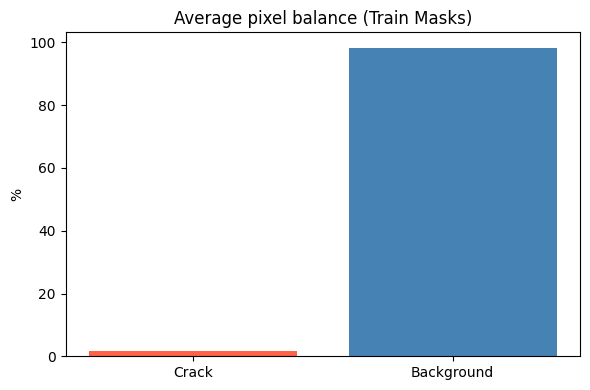

In [25]:
plt.figure(figsize=(6,4))
plt.bar(['Crack','Background'],
        [np.mean(crack_ratios),100-np.mean(crack_ratios)],
        color=['tomato','steelblue'])
plt.title('Average pixel balance (Train Masks)')
plt.ylabel('%')
plt.tight_layout()
plt.show()

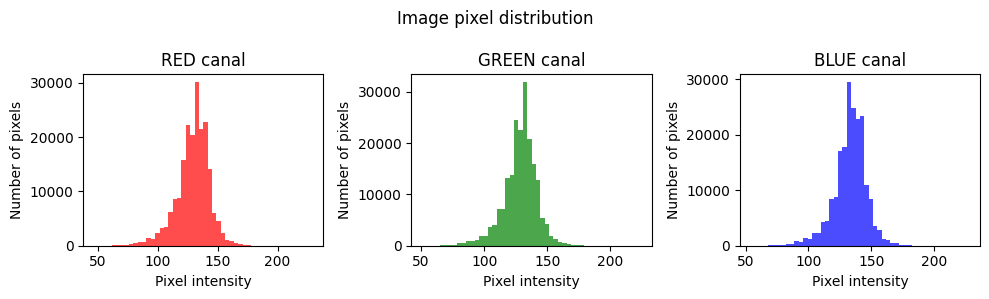

In [26]:
sample_arr = np.array(sample_img)
plt.figure(figsize=(10,3))
colors = ['red','green','blue']

for i,c in enumerate(colors):
  plt.subplot(1,3,i+1)
  plt.hist(sample_arr[:,:,i].ravel(), bins=50,color=c,alpha=0.7)
  plt.title(f'{c.upper()} canal')
  plt.xlabel('Pixel intensity')
  plt.ylabel('Number of pixels')

plt.suptitle('Image pixel distribution')
plt.tight_layout()
plt.show()

In [27]:
def conv_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, padding = 'same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(rate = 0.5)(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(rate = 0.5)(x)

    return x


def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = tf.keras.layers.MaxPool2D((2, 2))(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides = 2, padding = 'same')(inputs)
    x = tf.keras.layers.Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x



def build_unet(input_shape):
    inputs = tf.keras.layers.Input(shape = input_shape)


    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b1 = conv_block(p4, 512)

    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    outputs = tf.keras.layers.Conv2D(1, 1, padding = 'same', activation = 'sigmoid')(d4)

    model = tf.keras.models.Model(inputs, outputs, name = 'U-Net')
    return model


input_shape = (256, 256, 3)
model = build_unet(input_shape)

In [28]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)


    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # Threshold predictions

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = 0.0001),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)


model.fit(train_dataset, epochs = 5, validation_data = val_dataset)

Epoch 1/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 368s 473ms/step - dice_coef: 0.2138 - loss: 1.2685 - val_dice_coef: 0.1305 - val_loss: 1.1144
Epoch 2/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 233s 371ms/step - dice_coef: 0.3439 - loss: 1.0378 - val_dice_coef: 0.0569 - val_loss: 1.0900
Epoch 3/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 235s 375ms/step - dice_coef: 0.4670 - loss: 0.8945 - val_dice_coef: 0.1350 - val_loss: 1.0472
Epoch 4/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 235s 375ms/step - dice_coef: 0.5270 - loss: 0.7690 - val_dice_coef: 0.2399 - val_loss: 0.9431
Epoch 5/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 233s 371ms/step - dice_coef: 0.5633 - loss: 0.6758 - val_dice_coef: 0.2347 - val_loss: 0.9392


In [29]:
def conv_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, padding = 'same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('leaky_relu')(x)
    x = tf.keras.layers.Dropout(rate = 0.5)(x)


    x = tf.keras.layers.Conv2D(num_filters, 3, padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('leaky_relu')(x)
    x = tf.keras.layers.Dropout(rate = 0.5)(x)



    return x


def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = tf.keras.layers.MaxPool2D((2, 2))(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides = 2, padding = 'same')(inputs)
    x = tf.keras.layers.Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x


def build_unet(input_shape):
    inputs = tf.keras.layers.Input(shape = input_shape)


    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b1 = conv_block(p4, 512)

    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    outputs = tf.keras.layers.Conv2D(1, 1, padding = 'same', activation = 'sigmoid')(d4)

    model = tf.keras.models.Model(inputs, outputs, name = 'U-Net')
    return model


input_shape = (256, 256, 3)
model = build_unet(input_shape)

In [30]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # Threshold predictions

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice


model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate = 0.0001),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

model.fit(train_dataset, epochs = 5, validation_data = val_dataset)


Epoch 1/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 292s 415ms/step - dice_coef: 0.1751 - loss: 1.3526 - val_dice_coef: 0.0703 - val_loss: 1.1890
Epoch 2/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 237s 377ms/step - dice_coef: 0.2353 - loss: 1.1242 - val_dice_coef: 0.0697 - val_loss: 1.1050
Epoch 3/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 261s 377ms/step - dice_coef: 0.3399 - loss: 1.0008 - val_dice_coef: 0.1040 - val_loss: 1.0591
Epoch 4/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 240s 381ms/step - dice_coef: 0.4016 - loss: 0.9092 - val_dice_coef: 0.1071 - val_loss: 1.0375
Epoch 5/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 236s 376ms/step - dice_coef: 0.4454 - loss: 0.8303 - val_dice_coef: 0.1759 - val_loss: 0.9803


In [37]:
model.save('crack_detection.keras')

In [38]:
# Model Comparison
print("ReLU     — Val Dice: 0.2347 | Val Loss: 0.9392")
print("LeakyReLU— Val Dice: 0.1759 | Val Loss: 0.9803")
print("Winner: ReLU")

ReLU     — Val Dice: 0.2347 | Val Loss: 0.9392
LeakyReLU— Val Dice: 0.1759 | Val Loss: 0.9803
Winner: ReLU


In [39]:
!unzip '/content/crack_detection_lite.zip'

unzip:  cannot find or open /content/crack_detection_lite.zip, /content/crack_detection_lite.zip.zip or /content/crack_detection_lite.zip.ZIP.


In [40]:
from tensorflow.keras.models import load_model

custom_objects = {
    'bce_dice_loss': bce_dice_loss,
    'dice_coef': dice_coef
}

model = load_model("crack_detection.keras", custom_objects=custom_objects)


In [41]:
for image, mask in train_dataset.take(1):
    print(image.shape)

(16, 256, 256, 3)


In [44]:
def visualize_overlay_samples(image_dir, mask_dir, num_samples=3, alpha=0.8):
    image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
    mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])

    sample_indices = random.sample(range(len(image_paths)), num_samples)

    plt.figure(figsize=(8, num_samples * 3))

    for i, idx in enumerate(sample_indices):
        img, msk = load_image_mask(image_paths[idx], mask_paths[idx])

        img = img.numpy()
        msk = msk.numpy()
        # Make mask RGB (same shape as image)
        msk_rgb = tf.concat([msk, msk, msk], axis=-1).numpy()

        # Overlay: Image + (Mask * color)
        overlay = img.copy()
        # Change here: Assign to all 3 color channels
        overlay[msk_rgb[:,:,0] > 0.5] = [1.0, 0, 0]


        blended = (1 - alpha) * img + alpha * overlay

        plt.subplot(num_samples, 1, i+1)
        plt.imshow(blended)
        plt.title(f"Image {idx} with Mask Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

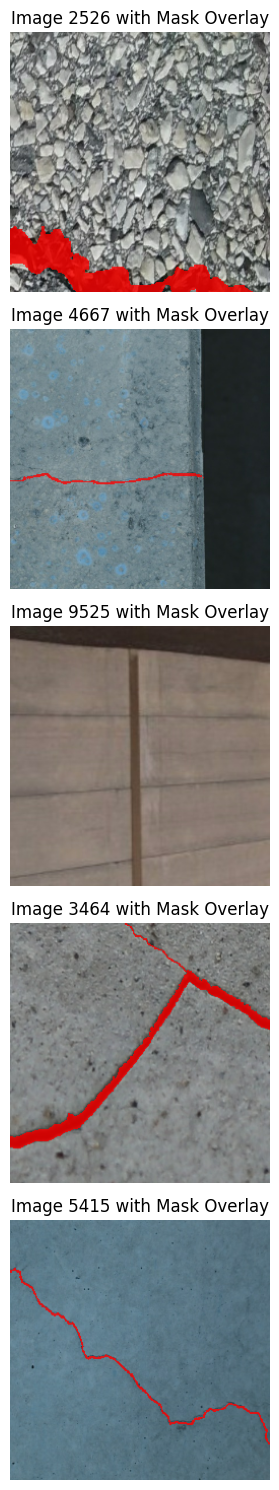

In [48]:
image_paths = '/content/Conglomerate Concrete Crack Detection/Train/images'
mask_paths = '/content/Conglomerate Concrete Crack Detection/Train/masks'


visualize_overlay_samples(
    image_dir=image_paths,
    mask_dir=mask_paths,
    num_samples=5
)


In [49]:
from sklearn.metrics import f1_score, precision_score, recall_score, jaccard_score
import numpy as np

y_true_all, y_pred_all = [], []

for img_batch, mask_batch in val_dataset:
    pred_batch = model.predict(img_batch, verbose=0)
    y_true_all.append(mask_batch.numpy().flatten())
    y_pred_all.append((pred_batch > 0.1).flatten())

y_true = np.concatenate(y_true_all).astype(int)
y_pred = np.concatenate(y_pred_all).astype(int)

print("=" * 40)
print(f"IoU (Jaccard) : {jaccard_score(y_true, y_pred):.4f}")
print(f"F1 Score      : {f1_score(y_true, y_pred):.4f}")
print(f"Precision     : {precision_score(y_true, y_pred):.4f}")
print(f"Recall        : {recall_score(y_true, y_pred):.4f}")
print("=" * 40)

IoU (Jaccard) : 0.0773
F1 Score      : 0.1435
Precision     : 0.1683
Recall        : 0.1250


In [50]:
print("""
=== Model Evaluation Results ===
Model    : U-Net (LeakyReLU, 5 epoch)
Threshold: 0.1

IoU (Jaccard) : 0.0773
F1 Score      : 0.1435
Precision     : 0.1683
Recall        : 0.1250

=== Room for Improvement ===
1. Epoch count is low (5) — model needs more training
2. LeakyReLU underperforms ReLU on this dataset
3. Dropout(0.5) is too high — causes underfitting
4. No data augmentation — poor generalization
5. Threshold 0.5 does not work — model confidence is low

=== Suggestions ===
1. Increase epochs to 20-30
2. Use ReLU activation
3. Reduce Dropout to 0.3
4. Add augmentation (flip, rotate, brightness)
5. Use learning rate scheduler
6. Apply transfer learning (ResNet / EfficientNet encoder)
7. Reduce batch size to 8 for better gradients
""")


=== Model Evaluation Results ===
Model    : U-Net (LeakyReLU, 5 epoch)
Threshold: 0.1

IoU (Jaccard) : 0.0773
F1 Score      : 0.1435
Precision     : 0.1683
Recall        : 0.1250

=== Room for Improvement ===
1. Epoch count is low (5) — model needs more training
2. LeakyReLU underperforms ReLU on this dataset
3. Dropout(0.5) is too high — causes underfitting
4. No data augmentation — poor generalization
5. Threshold 0.5 does not work — model confidence is low

=== Suggestions ===
1. Increase epochs to 20-30
2. Use ReLU activation
3. Reduce Dropout to 0.3
4. Add augmentation (flip, rotate, brightness)
5. Use learning rate scheduler
6. Apply transfer learning (ResNet / EfficientNet encoder)
7. Reduce batch size to 8 for better gradients



In [51]:
model.save('crack_detection.keras')

In [52]:
!unzip '/content/crack_detection_lite.zip'

unzip:  cannot find or open /content/crack_detection_lite.zip, /content/crack_detection_lite.zip.zip or /content/crack_detection_lite.zip.ZIP.


In [53]:
import zipfile

# Define filenames
model_filename = 'crack_detection.keras'
zip_filename = 'crack_detection_lite.zip'

# Create zip
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write(model_filename)

print(f'Model zipped successfully as {zip_filename}')


Model zipped successfully as crack_detection_lite.zip


In [54]:
def visualize_predictions(model, image_dir, mask_dir, num_samples=5, alpha=0.4):
    image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
    mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])

    sample_indices = random.sample(range(len(image_paths)), num_samples)

    plt.figure(figsize=(8, num_samples * 3))

    for i, idx in enumerate(sample_indices):
        # Load image and mask
        img, msk = load_image_mask(image_paths[idx], mask_paths[idx])

        # Get the model prediction (pred mask)
        pred_mask = model.predict(tf.expand_dims(img, axis=0))[0]

        img = img.numpy()
        msk = msk.numpy()

        224, 224, 3
        224, 224, 3
        msk_rgb = tf.concat([msk, msk, msk], axis=-1).numpy()
        pred_rgb = tf.concat([pred_mask, pred_mask, pred_mask], axis=-1)

        gt_overlay = img.copy()

        gt_overlay[msk_rgb[:,:,0] >= 0.5] = [1.0, 0, 0]

        pred_overlay = img.copy()
        pred_overlay[pred_rgb[:,:,0] >= 0.5] = [0, 1.0, 0]


        blended_gt = (1 - alpha) * img + alpha * gt_overlay

        # Blended (predicted mask overlay)
        blended_pred = (1 - alpha) * img + alpha * pred_overlay

        # Display ground truth and predicted mask overlays
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(blended_gt)
        plt.title(f"Ground Truth {idx}")
        plt.axis("off")

        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(blended_pred)
        plt.title(f"Prediction {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


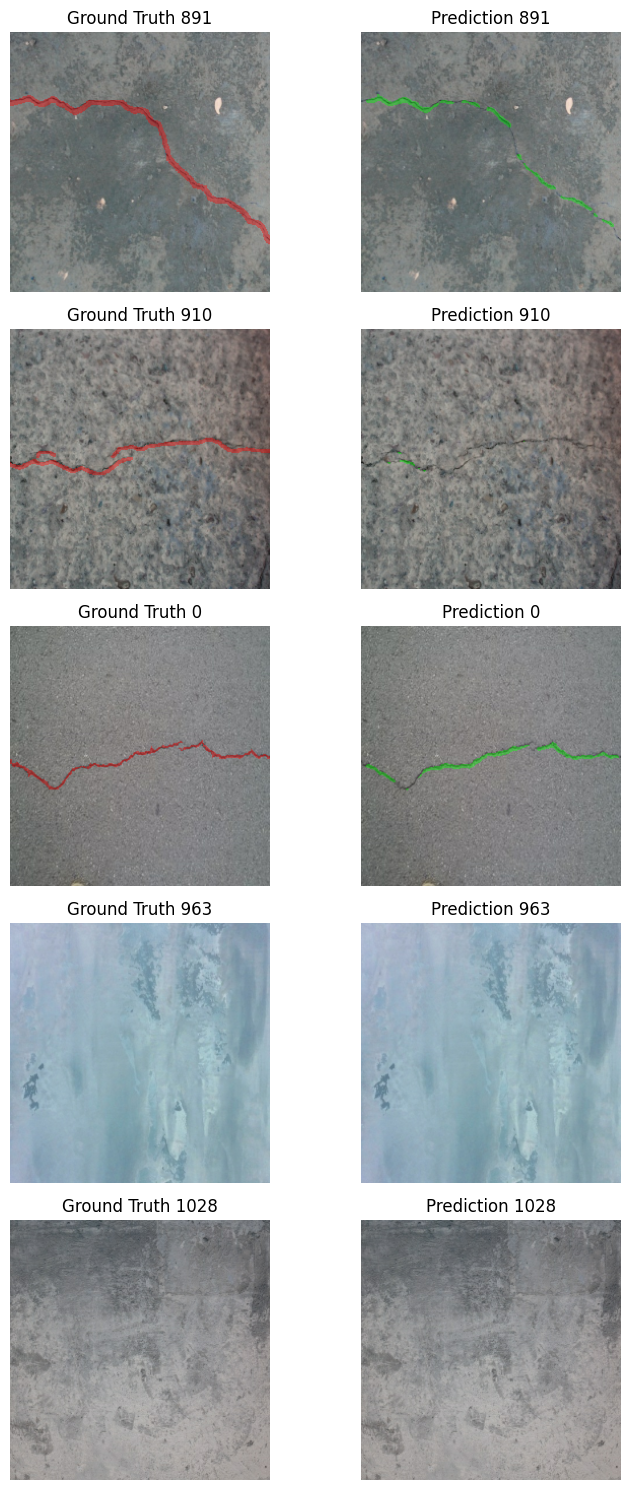

In [55]:
image_paths = '/content/Conglomerate Concrete Crack Detection/Test/images'
mask_paths = '/content/Conglomerate Concrete Crack Detection/Test/masks'


visualize_predictions(
    model=model,  # Your trained model
    image_dir=image_paths,
    mask_dir=mask_paths,
    num_samples=5
)

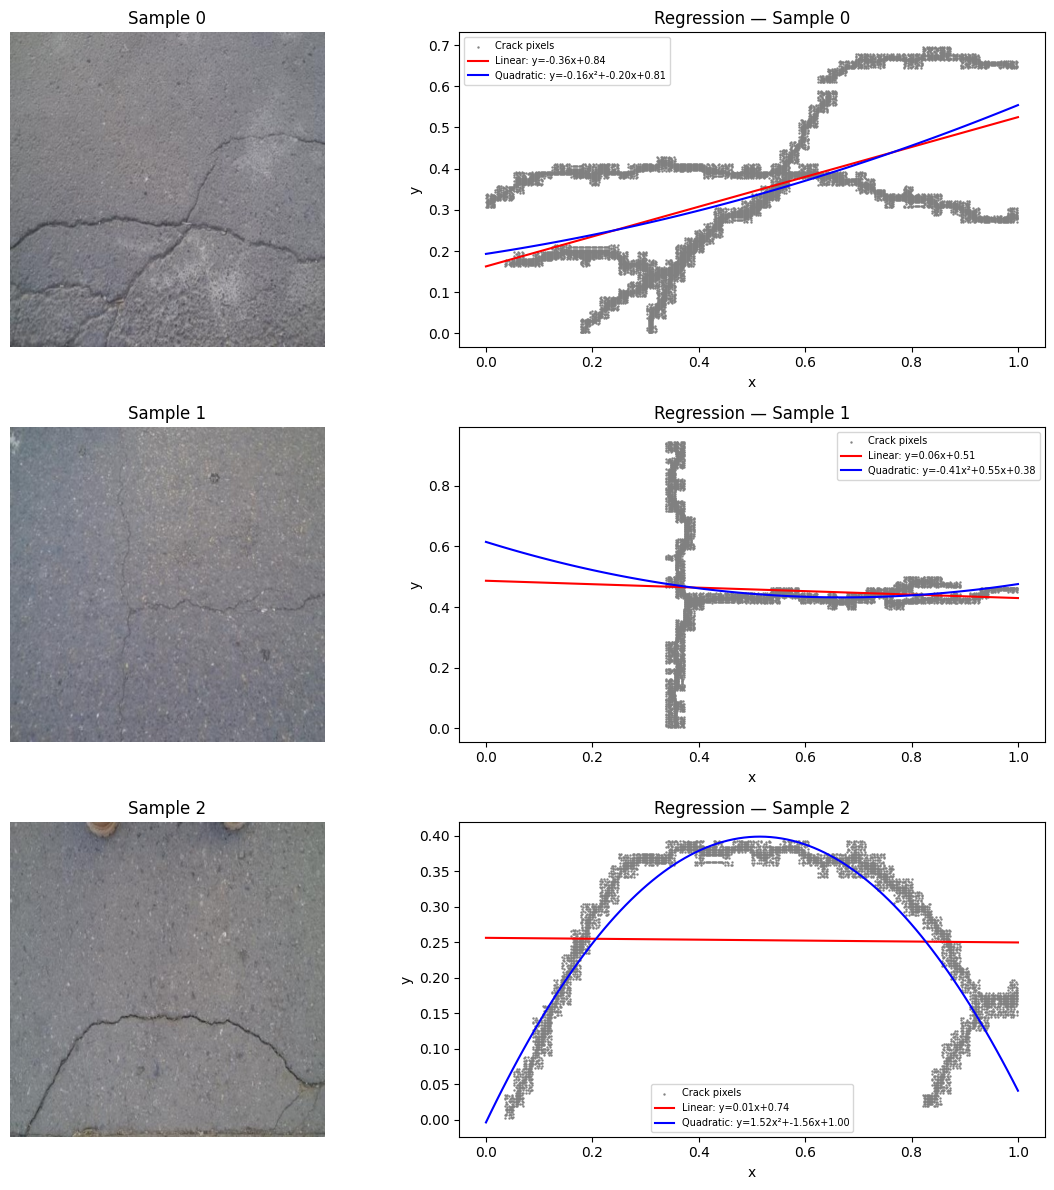

In [59]:
from scipy.optimize import curve_fit
import  random

base = '/content/Conglomerate Concrete Crack Detection'
mask_dir = f'{base}/Train/masks'
image_dir = f'{base}/Train/images'

mask_files = sorted(os.listdir(mask_dir))
image_files = sorted(os.listdir(image_dir))

def linear(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

# Crack pixel=3
valid = []
for idx in range(len(mask_files)):
    mask = np.array(plt.imread(f'{mask_dir}/{mask_files[idx]}'))
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    ys, xs = np.where(mask > 0.5)
    if len(xs) >= 100:
        valid.append(idx)
    if len(valid) == 3:
        break

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, idx in enumerate(valid):
    mask = np.array(plt.imread(f'{mask_dir}/{mask_files[idx]}'))
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    ys, xs = np.where(mask > 0.5)
    xs_n = xs / mask.shape[1]
    ys_n = ys / mask.shape[0]
    x_fit = np.linspace(0, 1, 100)

    popt_l, _ = curve_fit(linear, xs_n, ys_n)
    popt_q, _ = curve_fit(quadratic, xs_n, ys_n)

    img = plt.imread(f'{image_dir}/{image_files[idx]}')
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Sample {idx}')
    axes[i, 0].axis('off')

    axes[i, 1].scatter(xs_n, 1 - ys_n, s=0.5, c='gray', label='Crack pixels')
    axes[i, 1].plot(x_fit, 1 - linear(x_fit, *popt_l), 'r-',
                    label=f'Linear: y={popt_l[0]:.2f}x+{popt_l[1]:.2f}')
    axes[i, 1].plot(x_fit, 1 - quadratic(x_fit, *popt_q), 'b-',
                    label=f'Quadratic: y={popt_q[0]:.2f}x²+{popt_q[1]:.2f}x+{popt_q[2]:.2f}')
    axes[i, 1].legend(fontsize=7)
    axes[i, 1].set_title(f'Regression — Sample {idx}')
    axes[i, 1].set_xlabel('x')
    axes[i, 1].set_ylabel('y')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


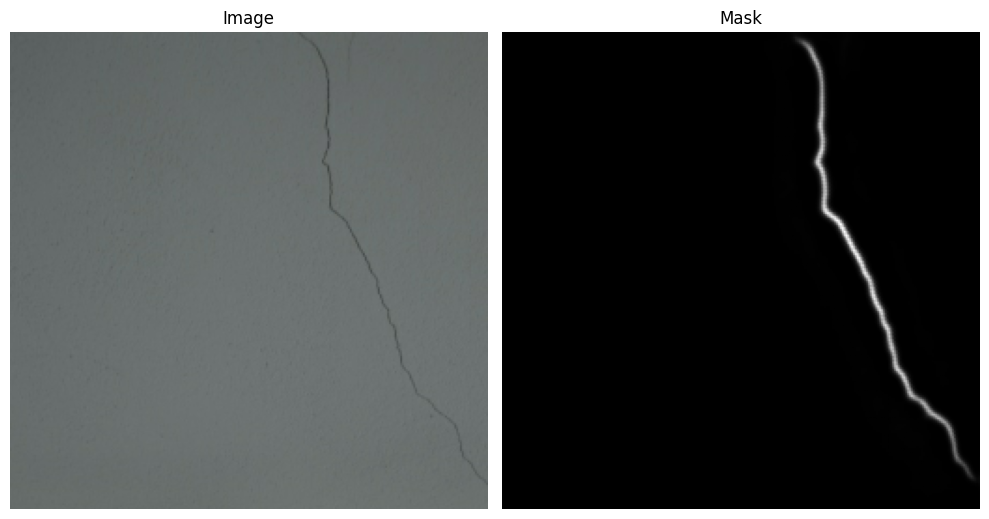

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np


image_paths = '/content/Conglomerate Concrete Crack Detection/Test/images'
mask_paths = '/content/Conglomerate Concrete Crack Detection/Test/masks'

image_paths = sorted([os.path.join(image_paths, fname) for fname in os.listdir(image_paths)])
mask_paths = sorted([os.path.join(mask_paths, fname) for fname in os.listdir(mask_paths)])


idx = random.sample(range(len(image_paths)), 1)

plt.figure(figsize = (10, 10))

idx = np.random.choice(len(image_paths))
img, msk = load_image_mask(image_paths[idx], mask_paths[idx])

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Image')
plt.axis('off')

plt.subplot(1, 2, 2)
# Add a new dimension to the image to create a batch of size 1
predicted_mask = model.predict(tf.expand_dims(img, axis=0))[0]
plt.imshow(predicted_mask, cmap = 'gray')
plt.title('Mask')
plt.axis('off')

plt.tight_layout()

In [ ]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # Threshold predictions

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice


model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[dice_coef]
)


<tf.Tensor: shape=(256, 256, 3), dtype=float32, numpy=
array([[[0.5002451 , 0.51985294, 0.50416666],
        [0.47726715, 0.496875  , 0.4811887 ],
        [0.47297794, 0.49258578, 0.4768995 ],
        ...,
        [0.47481617, 0.48658088, 0.50618875],
        [0.48682597, 0.49859068, 0.51819855],
        [0.459375  , 0.4711397 , 0.49074754]],

       [[0.4601103 , 0.47971815, 0.46403188],
        [0.46403188, 0.48363972, 0.46795344],
        [0.5146446 , 0.53425246, 0.5185662 ],
        ...,
        [0.49056372, 0.50232846, 0.5219363 ],
        [0.4759804 , 0.4877451 , 0.50735295],
        [0.42659312, 0.43835783, 0.45796567]],

       [[0.5081495 , 0.52775735, 0.5120711 ],
        [0.4807598 , 0.50036764, 0.48468137],
        [0.501348  , 0.52095586, 0.5052696 ],
        ...,
        [0.47640932, 0.48817402, 0.50778186],
        [0.46482843, 0.47659314, 0.49620098],
        [0.45533088, 0.46709558, 0.48670343]],

       ...,

       [[0.33370098, 0.33762255, 0.35330883],
        [0.30

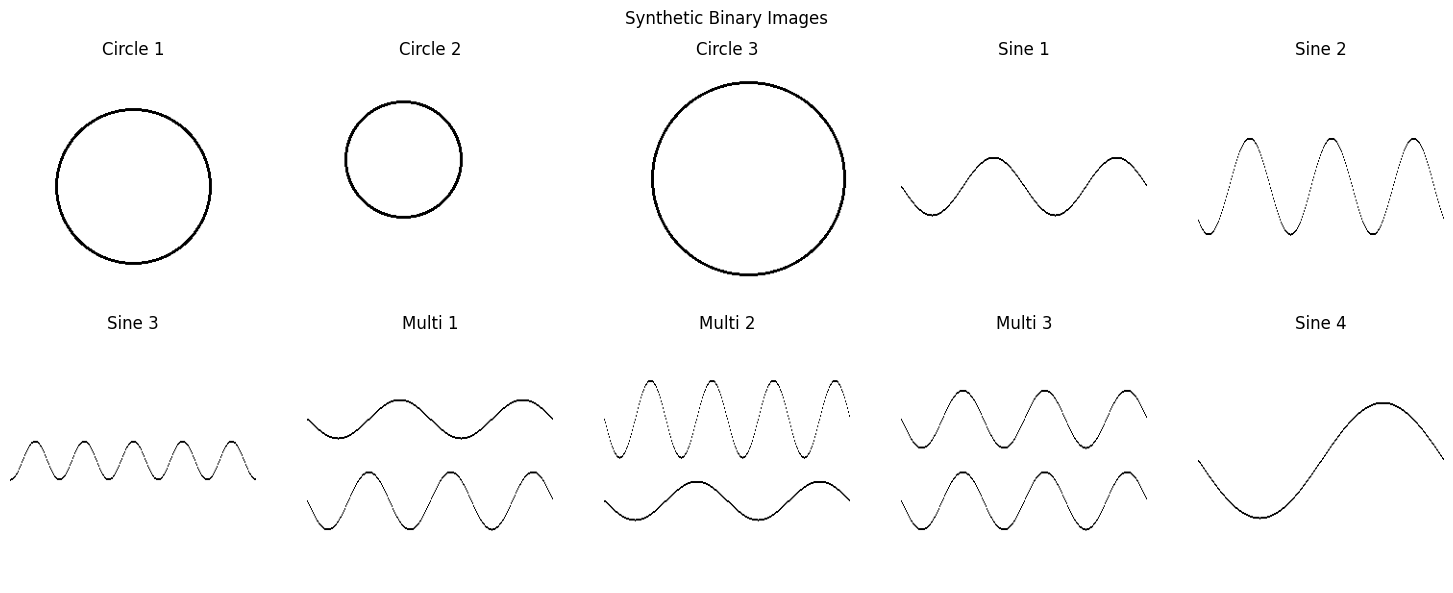

In [60]:
size = 256

def make_circle(cx, cy, r):
    img = np.zeros((size, size))
    for y in range(size):
        for x in range(size):
            if abs((x-cx)**2 + (y-cy)**2 - r**2) < r*3:
                img[y, x] = 1
    return img

def make_sine(a, f, p):
    img = np.zeros((size, size))
    for x in range(size):
        y = int(size//2 + a * np.sin(f * x / size * 2 * np.pi + p))
        if 0 <= y < size:
            img[y, x] = 1
            if y+1 < size: img[y+1, x] = 1
    return img

def make_multi(a1, f1, a2, f2):
    img = np.zeros((size, size))
    for x in range(size):
        y1 = int(size//3 + a1 * np.sin(f1 * x / size * 2 * np.pi))
        y2 = int(2*size//3 + a2 * np.sin(f2 * x / size * 2 * np.pi))
        for y in [y1, y2]:
            if 0 <= y < size:
                img[y, x] = 1
                if y+1 < size: img[y+1, x] = 1
    return img

images = [
    make_circle(128, 128, 80),
    make_circle(100, 100, 60),
    make_circle(150, 120, 100),
    make_sine(30, 2, 0),
    make_sine(50, 3, np.pi/4),
    make_sine(20, 5, np.pi/2),
    make_multi(20, 2, 30, 3),
    make_multi(40, 4, 20, 2),
    make_multi(30, 3, 30, 3),
    make_sine(60, 1, 0),
]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
titles = ['Circle 1', 'Circle 2', 'Circle 3',
          'Sine 1', 'Sine 2', 'Sine 3',
          'Multi 1', 'Multi 2', 'Multi 3', 'Sine 4']

for i, (img, ax) in enumerate(zip(images, axes.flatten())):
    ax.imshow(img, cmap='binary')
    ax.set_title(titles[i])
    ax.axis('off')

plt.suptitle('Synthetic Binary Images')
plt.tight_layout()
plt.show()

In [ ]:
idx

[4279]

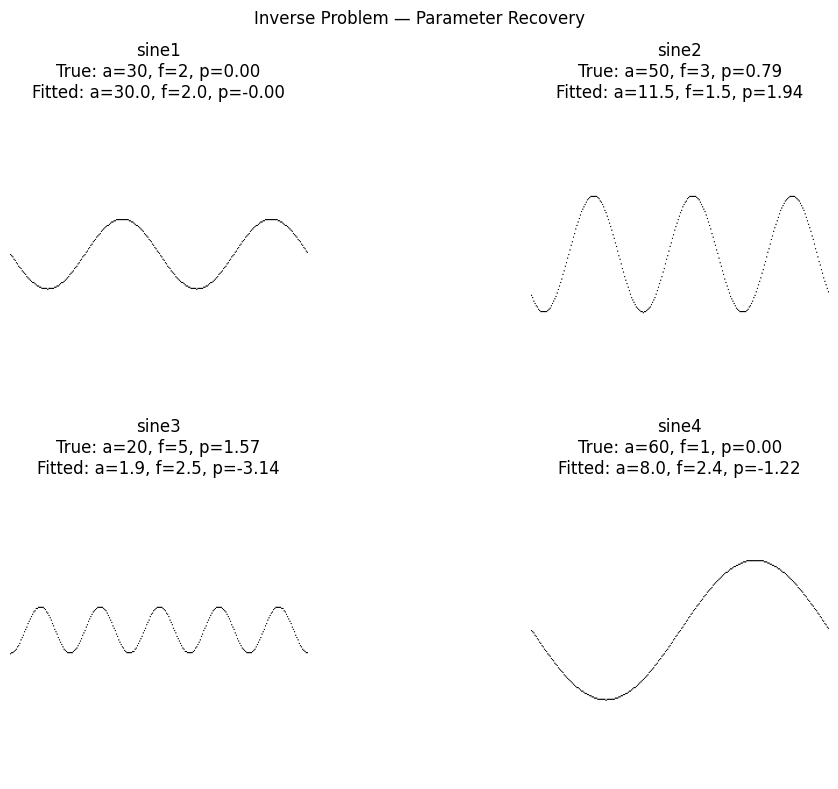

Name       True a    Fit a   True f    Fit f   True p    Fit p
------------------------------------------------------------
sine1       30.00    30.03     2.00     2.00     0.00    -0.00
sine2       50.00    11.51     3.00     1.54     0.79     1.94
sine3       20.00     1.85     5.00     2.53     1.57    -3.14
sine4       60.00     7.95     1.00     2.38     0.00    -1.22


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

size = 256

true_params = {
    'sine1': {'a': 30, 'f': 2, 'p': 0},
    'sine2': {'a': 50, 'f': 3, 'p': np.pi/4},
    'sine3': {'a': 20, 'f': 5, 'p': np.pi/2},
    'sine4': {'a': 60, 'f': 1, 'p': 0},
}

def sine_func(x, a, f, p):
    return size//2 + a * np.sin(f * x / size * 2 * np.pi + p)

results = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (name, params) in enumerate(true_params.items()):
    img = np.zeros((size, size))
    for x in range(size):
        y = int(size//2 + params['a'] * np.sin(params['f'] * x / size * 2 * np.pi + params['p']))
        if 0 <= y < size:
            img[y, x] = 1

    ys, xs = np.where(img > 0.5)

    try:
        popt, _ = curve_fit(sine_func, xs, ys,
                            p0=[30, 2, 0],
                            bounds=([0, 0, -np.pi], [100, 10, np.pi]))
        a_fit, f_fit, p_fit = popt
    except:
        a_fit, f_fit, p_fit = 0, 0, 0

    results[name] = {'true': (params['a'], params['f'], params['p']),
                     'fitted': (a_fit, f_fit, p_fit)}

    ax = axes.flatten()[i]
    ax.imshow(img, cmap='binary')
    ax.set_title(f"{name}\nTrue: a={params['a']}, f={params['f']}, p={params['p']:.2f}\n"
                 f"Fitted: a={a_fit:.1f}, f={f_fit:.1f}, p={p_fit:.2f}")
    ax.axis('off')

plt.suptitle('Inverse Problem — Parameter Recovery')
plt.tight_layout()
plt.show()

print(f"{'Name':<8} {'True a':>8} {'Fit a':>8} {'True f':>8} {'Fit f':>8} {'True p':>8} {'Fit p':>8}")
print("-" * 60)
for name, r in results.items():
    ta, tf, tp = r['true']
    fa, ff, fp = r['fitted']
    print(f"{name:<8} {ta:>8.2f} {fa:>8.2f} {tf:>8.2f} {ff:>8.2f} {tp:>8.2f} {fp:>8.2f}")